In [5]:
import torch
from final.dataset import SolarLSTMDataset
import pandas as pd
import torch.nn as nn

In [2]:
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("dataset/final.csv")

In [14]:
df.head()

,Unnamed: 0,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,TOA_SW_DWN,T2M,RH2M,QV2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_LW_DWN,ALLSKY_SRF_ALB
0,0,0.0,0.0,0.0,0.0,25.91,93.01,19.62,99.84,2.42,99.90,430.65,-999.0
1,1,0.0,0.0,0.0,0.0,25.72,93.74,19.56,99.79,2.42,99.98,427.98,-999.0
2,2,0.0,0.0,0.0,0.0,25.54,94.37,19.49,99.75,2.38,100.00,428.50,-999.0
3,3,0.0,0.0,0.0,0.0,25.39,94.79,19.40,99.76,2.25,100.00,425.83,-999.0
4,4,0.0,0.0,0.0,0.0,25.23,95.24,19.30,99.79,2.05,99.95,424.73,-999.0


In [16]:
df = df.drop('Unnamed: 0',axis=1)

In [22]:
len(df)

237168

In [20]:
import seaborn as sns

<Axes: >

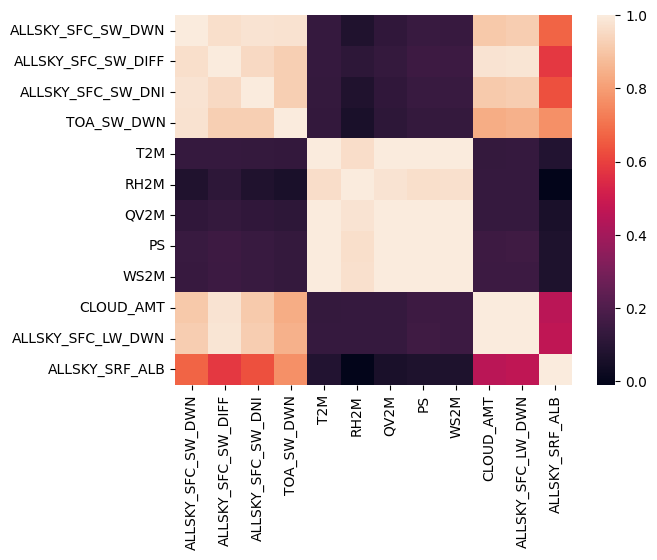

In [21]:
sns.heatmap(data)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

counts, bin_edges = np.histogram(df["ALLSKY_SFC_SW_DWN"], bins=50)
hist_dict = {
    "bin_edges": bin_edges.tolist(),
    "counts": counts.tolist()
}


In [8]:
import joblib
import pandas as pd
from dataset import SolarLSTMDataset

# Load your preprocessed dataset
df = pd.read_csv("dataset/final.csv")  # replace with your full dataset path
df['datetime'] = pd.to_datetime( df['datetime'])
# Create dataset instance (this fits the scaler inside)
dataset = SolarLSTMDataset(df)

# Save the fitted scaler
joblib.dump(dataset.scaler, "scalers/feature_scaler.pkl")

print("✅ Scaler saved to scalers/feature_scaler.pkl")


✅ Scaler saved to scalers/feature_scaler.pkl


a:\weather_net\dataset.py:45: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  self.X = torch.tensor(self.X, dtype=torch.float32)


In [9]:
hist_dict

{'bin_edges': [-999.0,
  -957.9436000000001,
  -916.8872,
  -875.8308,
  -834.7744,
  -793.7180000000001,
  -752.6616,
  -711.6052,
  -670.5488,
  -629.4924000000001,
  -588.436,
  -547.3796,
  -506.32320000000004,
  -465.2668000000001,
  -424.21040000000005,
  -383.154,
  -342.09760000000006,
  -301.0412000000001,
  -259.98480000000006,
  -218.9284,
  -177.87200000000007,
  -136.81560000000013,
  -95.75920000000008,
  -54.702800000000025,
  -13.646400000000085,
  27.409999999999854,
  68.4663999999998,
  109.52279999999996,
  150.5791999999999,
  191.63559999999984,
  232.692,
  273.74839999999995,
  314.8047999999999,
  355.8611999999998,
  396.91759999999977,
  437.97399999999993,
  479.0303999999999,
  520.0867999999998,
  561.1432,
  602.1995999999999,
  643.2559999999999,
  684.3123999999998,
  725.3687999999997,
  766.4251999999999,
  807.4815999999998,
  848.5379999999998,
  889.5944,
  930.6507999999999,
  971.7071999999998,
  1012.7635999999998,
  1053.82],
 'counts': [61560,

In [10]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [11]:
df.head()

,Unnamed: 0,datetime,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,TOA_SW_DWN,T2M,RH2M,QV2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_LW_DWN,ALLSKY_SRF_ALB
0,0,2024-08-02 00:00:00,0.0,0.0,0.0,0.0,25.91,93.01,19.62,99.84,2.42,99.90,430.65,-999.0
1,1,2024-08-02 01:00:00,0.0,0.0,0.0,0.0,25.72,93.74,19.56,99.79,2.42,99.98,427.98,-999.0
2,2,2024-08-02 02:00:00,0.0,0.0,0.0,0.0,25.54,94.37,19.49,99.75,2.38,100.00,428.50,-999.0
3,3,2024-08-02 03:00:00,0.0,0.0,0.0,0.0,25.39,94.79,19.40,99.76,2.25,100.00,425.83,-999.0
4,4,2024-08-02 04:00:00,0.0,0.0,0.0,0.0,25.23,95.24,19.30,99.79,2.05,99.95,424.73,-999.0


In [12]:
def train_model(model, train_loader, val_loader, data,epochs=20, lr=0.001, device='cuda',offset = 0):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            preds = model(X)
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X.size(0)
        
        train_loss /= len(train_loader.dataset)

        val_loss = evaluate_model(model, val_loader, criterion, device)
        data[epoch+offset]=train_loss
        print(f"Epoch {epoch+1+offset}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

def evaluate_model(model, val_loader, criterion, device='cuda'):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = criterion(preds, y)
            val_loss += loss.item() * X.size(0)
    return val_loss / len(val_loader.dataset)


In [13]:
from torch.utils.data import DataLoader, random_split
import pandas as pd
df['datetime'] = pd.to_datetime(df['datetime'])
dataset = SolarLSTMDataset(df, seq_len=24)

# Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

# Model
input_size = dataset.X.shape[2]
model = TimeSeriesTransformer(input_size=input_size)

# Train


KeyboardInterrupt: 

In [ ]:
dataset.X.shape

torch.Size([87791, 24, 14])

In [ ]:
data ={}

In [ ]:

train_model(model, train_loader, val_loader, epochs=10, lr=0.01,data=data,offset=len(data))


Epoch 1: Train Loss = 72266.3913, Val Loss = 57062.7569
Epoch 2: Train Loss = 68498.8238, Val Loss = 70040.2433
Epoch 3: Train Loss = 71382.8016, Val Loss = 69964.5373


In [ ]:
import matplotlib.pyplot as plt

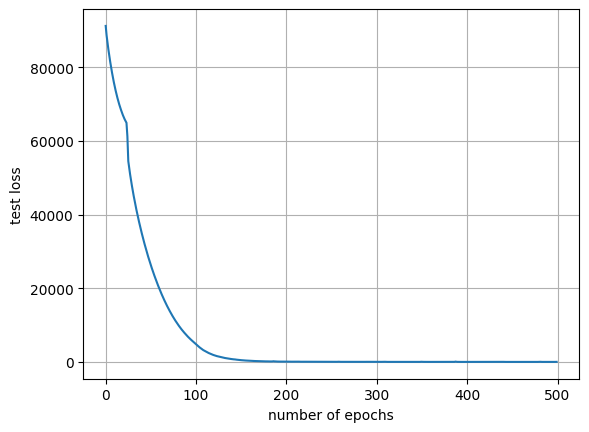

In [ ]:
plt.plot(list(data.keys()),list(data.values()))
plt.xlabel("number of epochs")
plt.ylabel("test loss")
plt.grid(True)

In [ ]:
torch.save(model.state_dict(),"models/version2.pth")

In [ ]:
loss_fn = nn.MSELoss()

In [ ]:
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to('cuda'), y.to('cuda')
        preds = model(X)
        print(preds[0])
        loss = loss_fn(preds, y)


tensor([171.0810], device='cuda:0')
tensor([755.2513], device='cuda:0')
tensor([0.0577], device='cuda:0')
tensor([-0.9592], device='cuda:0')
tensor([101.6121], device='cuda:0')
tensor([616.3111], device='cuda:0')
tensor([-0.9835], device='cuda:0')
tensor([366.2784], device='cuda:0')
tensor([-0.1612], device='cuda:0')
tensor([190.4381], device='cuda:0')
tensor([-0.9851], device='cuda:0')
tensor([-0.4384], device='cuda:0')
tensor([894.7984], device='cuda:0')
tensor([-0.3301], device='cuda:0')
tensor([-1.1211], device='cuda:0')
tensor([396.7848], device='cuda:0')
tensor([124.4957], device='cuda:0')
tensor([-0.5442], device='cuda:0')
tensor([-0.9899], device='cuda:0')
tensor([505.3874], device='cuda:0')
tensor([718.7461], device='cuda:0')
tensor([586.3856], device='cuda:0')
tensor([-0.3217], device='cuda:0')
tensor([286.5681], device='cuda:0')
tensor([18.1698], device='cuda:0')
tensor([24.6909], device='cuda:0')
tensor([-0.8661], device='cuda:0')
tensor([-0.0263], device='cuda:0')


In [ ]:
model = TimeSeriesTransformer(14)

In [ ]:
model.load_state_dict(torch.load("models/version2.pth"))

C:\Users\grins\AppData\Local\Temp\ipykernel_19148\3839182896.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/version2.pth"))


<All keys matched successfully>

In [ ]:
from eval import evaluate_and_plot

In [ ]:
model.to('cuda')

TimeSeriesTransformer(
  (input_proj): Linear(in_features=14, out_features=128, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features

RMSE: 24.0718
MAE : 15.7112


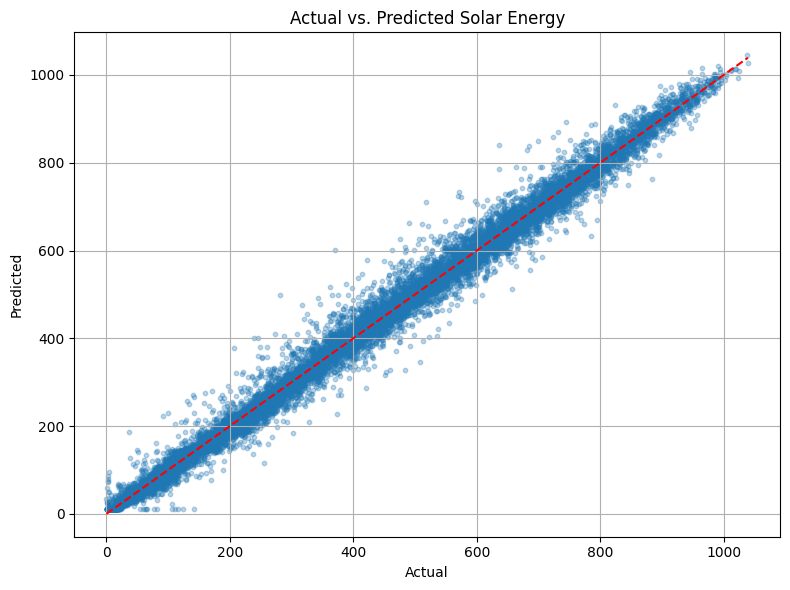

In [ ]:
evaluate_and_plot(model=model,val_loader=val_loader,device='cuda')

In [ ]:
import numpy as np

In [ ]:
df = df.replace(-999.0,np.nan).dropna().reset_index()

In [ ]:
df.head()

,index,Unnamed: 0,datetime,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,TOA_SW_DWN,T2M,RH2M,QV2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_LW_DWN,ALLSKY_SRF_ALB
0,5,5,2024-08-02 05:00:00,5.57,7.25,0.00,61.25,25.28,94.97,19.29,99.86,2.05,100.00,424.20,0.14
1,6,6,2024-08-02 06:00:00,62.12,53.58,4.74,352.55,26.03,91.98,19.52,99.94,2.66,98.96,427.17,0.13
2,7,7,2024-08-02 07:00:00,149.30,122.25,2.21,649.95,27.08,86.96,19.62,100.00,3.38,99.82,432.52,0.13
3,8,8,2024-08-02 08:00:00,264.67,205.73,0.00,910.85,28.47,79.24,19.38,100.03,4.37,100.00,438.95,0.13
4,9,9,2024-08-02 09:00:00,329.05,245.81,0.00,1117.45,29.86,72.74,19.28,100.02,4.76,100.00,446.02,0.13


In [ ]:
df.index = df['datetime']

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure your datetime index is properly set
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.replace(-999.0,np.nan).dropna()
# Extract hour from index
df['hour'] = df.index.hour

# Group by hour and calculate mean solar output


In [ ]:
df.head()

,index,Unnamed: 0,datetime,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DIFF,ALLSKY_SFC_SW_DNI,TOA_SW_DWN,T2M,RH2M,QV2M,PS,WS2M,CLOUD_AMT,ALLSKY_SFC_LW_DWN,ALLSKY_SRF_ALB,hour
datetime,,,,,,,,,,,,,,,,
2024-08-02 05:00:00,5,5,2024-08-02 05:00:00,5.57,7.25,0.00,61.25,25.28,94.97,19.29,99.86,2.05,100.00,424.20,0.14,0
2024-08-02 06:00:00,6,6,2024-08-02 06:00:00,62.12,53.58,4.74,352.55,26.03,91.98,19.52,99.94,2.66,98.96,427.17,0.13,0
2024-08-02 07:00:00,7,7,2024-08-02 07:00:00,149.30,122.25,2.21,649.95,27.08,86.96,19.62,100.00,3.38,99.82,432.52,0.13,0
2024-08-02 08:00:00,8,8,2024-08-02 08:00:00,264.67,205.73,0.00,910.85,28.47,79.24,19.38,100.03,4.37,100.00,438.95,0.13,0
2024-08-02 09:00:00,9,9,2024-08-02 09:00:00,329.05,245.81,0.00,1117.45,29.86,72.74,19.28,100.02,4.76,100.00,446.02,0.13,0


In [ ]:
from fetch import fetch_and_save

In [ ]:
df = fetch_and_save(
        parameter="ALLSKY_SFC_SW_DWN",  # Global solar radiation (W/m^2)
        latitude=18.5204,               # Pune latitude
        longitude=73.8567,              # Pune longitude
        location_name="Pune",
        days_ago=4
    )

🔍 Fetching ALLSKY_SFC_SW_DWN from 4 days ago for Pune
📡 Request: https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=ALLSKY_SFC_SW_DWN&community=RE&latitude=18.5204&longitude=73.8567&start=20250729&end=20250729&format=JSON


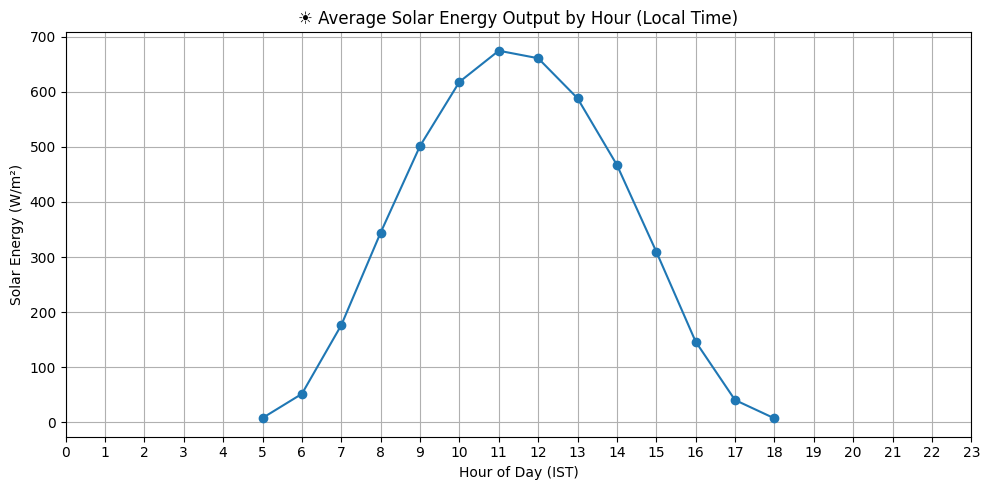

In [ ]:
# Extract hour after timezone conversion
df['hour'] = df.index.hour

# Group by hour and calculate mean solar output
hourly_avg = df.groupby('hour')['ALLSKY_SFC_SW_DWN'].mean()

# Plot
plt.figure(figsize=(10, 5))
hourly_avg.plot(kind='line', marker='o')
plt.title("☀️ Average Solar Energy Output by Hour (Local Time)")
plt.xlabel("Hour of Day (IST)")
plt.ylabel("Solar Energy (W/m²)")
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

In [1]:
from final_fetch import fetch_weatherbit_data

In [ ]:
for i in range(7):
    fetch_weatherbit_data()

In [23]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone

In [24]:
from datetime import datetime, timedelta

now = datetime.now()
today_midnight = datetime(now.year, now.month, now.day)
yesterday_midnight = today_midnight - timedelta(days=1)


print("Yesterday midnight:", yesterday_midnight)
print("Today midnight:", today_midnight)

Yesterday midnight: 2025-08-08 00:00:00
Today midnight: 2025-08-09 00:00:00


In [25]:
API_URL = "https://api.weatherbit.io/v2.0/history/hourly"
API_KEY = "777628119ce049d484833355dbeca175"
LAT = 28.6139
LON = 77.2090

In [26]:
from datetime import datetime,timedelta
import requests

In [27]:
def compute_additional_features(df):
    df['RH2M'] = df['rh']
    df['PS'] = df['pres']
    df['T2M'] = df['temp']
    df['WS2M'] = df['wind_spd']
    df['CLOUD_AMT'] = df['clouds']
    df['ALLSKY_SFC_SW_DWN'] = df['ghi']
    df['ALLSKY_SFC_SW_DNI'] = df['dni']
    df['ALLSKY_SFC_SW_DIFF'] = df['dhi']

    T = df['temp']
    RH = df['rh'] / 100.0
    P = df['pres']
    es = 6.112 * np.exp((17.67 * T) / (T + 243.5))
    e = RH * es
    qv = (0.622 * e) / (P - (1 - 0.622) * e)
    df['QV2M'] = qv

    df['TOA_SW_DWN'] = df['solar_rad'].fillna(0)

    sigma = 5.67e-8
    temp_K = df['temp'] + 273.15
    emissivity = 0.7 + 0.2 * (RH ** (1/7))
    df['ALLSKY_SFC_LW_DWN'] = emissivity * sigma * (temp_K ** 4)

    return df


In [28]:
def add_time_features(df):
    df['hour'] = df.index.hour
    df['month'] = df.index.month
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

In [29]:
def evaluation_fetch(lat, lon, key):
    now = datetime.now()
    today_midnight = datetime(now.year, now.month, now.day)
    yesterday_midnight = today_midnight - timedelta(days=25)
    print(yesterday_midnight)
    print(today_midnight)
    params = {
        "lat": lat,
        "lon": lon,
        "key": key,
        "start_date": yesterday_midnight
        .strftime("%Y-%m-%d:%H"),
        "end_date": today_midnight.strftime("%Y-%m-%d:%H")
    }

    r = requests.get(API_URL, params=params)
    print(r.url)
    r.raise_for_status()
    data = r.json()['data']

    df = pd.DataFrame(data)
    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
    df.set_index('timestamp_utc', inplace=True)

    df = add_time_features(df)
    df = compute_additional_features(df)
    print(df.columns)
    return df,data


In [30]:
df,data = evaluation_fetch(18.53,73.18,"777628119ce049d484833355dbeca175")

2025-07-15 00:00:00
2025-08-09 00:00:00
https://api.weatherbit.io/v2.0/history/hourly?lat=18.53&lon=73.18&key=777628119ce049d484833355dbeca175&start_date=2025-07-15%3A00&end_date=2025-08-09%3A00
Index(['app_temp', 'azimuth', 'clouds', 'datetime', 'dewpt', 'dhi', 'dni',
       'elev_angle', 'ghi', 'h_angle', 'pod', 'precip', 'pres',
       'revision_status', 'revision_version', 'rh', 'slp', 'snow', 'solar_rad',
       'temp', 'timestamp_local', 'ts', 'uv', 'vis', 'weather', 'wind_dir',
       'wind_gust_spd', 'wind_spd', 'hour', 'month', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'RH2M', 'PS', 'T2M', 'WS2M', 'CLOUD_AMT',
       'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_SW_DNI', 'ALLSKY_SFC_SW_DIFF', 'QV2M',
       'TOA_SW_DWN', 'ALLSKY_SFC_LW_DWN'],
      dtype='object')


In [31]:
df = pd.DataFrame(data)

In [32]:
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)


In [33]:
df.set_index('timestamp_utc', inplace=True)

In [34]:
df = add_time_features(df)


In [35]:
df = compute_additional_features(df)

In [36]:
len(df)

600

In [37]:
df['solar_rad']

timestamp_utc
2025-07-15 00:00:00+00:00     0
2025-07-15 01:00:00+00:00    24
2025-07-15 02:00:00+00:00    48
2025-07-15 03:00:00+00:00    43
2025-07-15 04:00:00+00:00    50
                             ..
2025-08-08 19:00:00+00:00     0
2025-08-08 20:00:00+00:00     0
2025-08-08 21:00:00+00:00     0
2025-08-08 22:00:00+00:00     0
2025-08-08 23:00:00+00:00     0
Name: solar_rad, Length: 600, dtype: int64

In [38]:

FEATURES = [
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI", "TOA_SW_DWN",
    "RH2M", "QV2M", "PS", "WS2M", "CLOUD_AMT",
    "ALLSKY_SFC_LW_DWN", "T2M", "hour_sin", "hour_cos", "month_sin", "month_cos"
]

In [39]:
MODEL_PATH = "models/best_deep (3).pth"
SCALER_PATH = "scalers/feature_scaler.pkl"
SEQ_LEN = 24
FEATURES = [
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI", "TOA_SW_DWN",
    "RH2M", "QV2M", "PS", "WS2M", "CLOUD_AMT",
    "ALLSKY_SFC_LW_DWN", "T2M", "hour_sin", "hour_cos", "month_sin", "month_cos"
]
TARGET = "ALLSKY_SFC_SW_DWN"

In [40]:
def prepare_input(df, scaler):
    df = df[FEATURES]
    df_scaled = scaler.transform(df)
    tensor = torch.tensor(df_scaled[-SEQ_LEN:], dtype=torch.float32,device='cpu').unsqueeze(0)
    return tensor
def predict(model, input_tensor):
    with torch.no_grad():
        output = model(input_tensor).item()
        return output

In [41]:
from model_4 import DeepSolarModel

ModuleNotFoundError: No module named 'model_4'

In [ ]:
model = DeepSolarModel(len(FEATURES))

In [ ]:
model.state_dict().keys()

odict_keys(['cnn.0.weight', 'cnn.0.bias', 'cnn.2.weight', 'cnn.2.bias', 'cnn.2.running_mean', 'cnn.2.running_var', 'cnn.2.num_batches_tracked', 'cnn.3.weight', 'cnn.3.bias', 'cnn.5.weight', 'cnn.5.bias', 'cnn.5.running_mean', 'cnn.5.running_var', 'cnn.5.num_batches_tracked', 'cnn.6.weight', 'cnn.6.bias', 'cnn.8.weight', 'cnn.8.bias', 'cnn.8.running_mean', 'cnn.8.running_var', 'cnn.8.num_batches_tracked', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l0_reverse', 'lstm.weight_hh_l0_reverse', 'lstm.bias_ih_l0_reverse', 'lstm.bias_hh_l0_reverse', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'lstm.weight_ih_l1_reverse', 'lstm.weight_hh_l1_reverse', 'lstm.bias_ih_l1_reverse', 'lstm.bias_hh_l1_reverse', 'lstm.weight_ih_l2', 'lstm.weight_hh_l2', 'lstm.bias_ih_l2', 'lstm.bias_hh_l2', 'lstm.weight_ih_l2_reverse', 'lstm.weight_hh_l2_reverse', 'lstm.bias_ih_l2_reverse', 'lstm.bias_hh_l2_reverse', 'lstm.weight_ih_

In [ ]:
import matplotlib.pyplot as plt
import joblib
import torch

In [52]:
MODEL_PATH = "models/best_spike_aware_1.pth"

In [53]:
data = torch.load(MODEL_PATH)

C:\Users\grins\AppData\Local\Temp\ipykernel_13492\2067981046.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(MODEL_PATH)


In [54]:
data.keys()

odict_keys(['cnn_small.weight', 'cnn_small.bias', 'cnn_med.weight', 'cnn_med.bias', 'cnn_dil.weight', 'cnn_dil.bias', 'bn.weight', 'bn.bias', 'bn.running_mean', 'bn.running_var', 'bn.num_batches_tracked', 'lstm.weight_ih_l0', 'lstm.weight_hh_l0', 'lstm.bias_ih_l0', 'lstm.bias_hh_l0', 'lstm.weight_ih_l0_reverse', 'lstm.weight_hh_l0_reverse', 'lstm.bias_ih_l0_reverse', 'lstm.bias_hh_l0_reverse', 'lstm.weight_ih_l1', 'lstm.weight_hh_l1', 'lstm.bias_ih_l1', 'lstm.bias_hh_l1', 'lstm.weight_ih_l1_reverse', 'lstm.weight_hh_l1_reverse', 'lstm.bias_ih_l1_reverse', 'lstm.bias_hh_l1_reverse', 'lstm.weight_ih_l2', 'lstm.weight_hh_l2', 'lstm.bias_ih_l2', 'lstm.bias_hh_l2', 'lstm.weight_ih_l2_reverse', 'lstm.weight_hh_l2_reverse', 'lstm.bias_ih_l2_reverse', 'lstm.bias_hh_l2_reverse', 'attn.in_proj_weight', 'attn.in_proj_bias', 'attn.out_proj.weight', 'attn.out_proj.bias', 'fc.0.weight', 'fc.0.bias', 'fc.3.weight', 'fc.3.bias', 'fc.6.weight', 'fc.6.bias'])

In [55]:
from models_code.model_5 import SpikeAwareHybrid

In [56]:
model = SpikeAwareHybrid(len(FEATURES))

In [57]:
model.load_state_dict(data)

<All keys matched successfully>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.init as init
from collections import defaultdict

MODEL_PATH = "models/best_deep (2).pth"  # your checkpoint path

def smart_partial_load(model, ckpt_path, verbose=True):
    ckpt = torch.load(ckpt_path, map_location='cpu')
    sd = ckpt.get("model_state", ckpt.get("state_dict", ckpt))

    model_sd = model.state_dict()
    loaded_keys = []
    smart_copied = []
    skipped = []
    for k, target in model_sd.items():
        if k in sd:
            src = sd[k]
            if tuple(src.shape) == tuple(target.shape):
                model_sd[k] = src
                loaded_keys.append(k)
            else:
                # Try smart-copy for 1D and 2D tensors
                if src.ndim == target.ndim and src.ndim in (1, 2):
                    new_t = target.clone()
                    if src.ndim == 2:
                        r = min(src.shape[0], new_t.shape[0])
                        c = min(src.shape[1], new_t.shape[1])
                        new_t[:r, :c] = src[:r, :c]
                    else:  # 1D
                        r = min(src.shape[0], new_t.shape[0])
                        new_t[:r] = src[:r]
                    model_sd[k] = new_t
                    smart_copied.append((k, tuple(src.shape), tuple(target.shape)))
                else:
                    # incompatible shape / dimension -> skip
                    skipped.append((k, tuple(src.shape), tuple(target.shape)))
        else:
            # key missing in checkpoint
            skipped.append((k, None, tuple(target.shape)))

    # load updated state dict (non-strict because we may not have exact ckpt-to-model match)
    model.load_state_dict(model_sd, strict=False)

    # Re-init params that were skipped (so they aren't left partially weird)
    def reinit_skipped_params(model, skipped_info):
        for k, src_shape, tgt_shape in skipped_info:
            # only reinit parameters actually in model (they are)
            p = dict(model.named_parameters()).get(k, None)
            if p is None:
                # might be a buffer (like running_mean in BN). try buffers
                b = dict(model.named_buffers()).get(k, None)
                if b is not None:
                    continue
                else:
                    continue
            with torch.no_grad():
                if p.ndim > 1:
                    init.kaiming_uniform_(p)
                else:
                    init.zeros_(p)

    reinit_skipped_params(model, [s for s in skipped if s[0] in dict(model.named_parameters())])

    # Reporting
    if verbose:
        print(f"Total model params: {len(model_sd)}")
        print(f"Exact-loaded keys: {len(loaded_keys)}")
        if loaded_keys:
            print("  examples:", loaded_keys[:6])
        print(f"Smart-copied keys: {len(smart_copied)}")
        for item in smart_copied:
            print(f"  smart-copied {item[0]}  ckpt_shape={item[1]} -> model_shape={item[2]}")
        print(f"Skipped / missing keys: {len(skipped)}")
        for item in skipped[:10]:
            print(f"  skipped {item[0]}  ckpt_shape={item[1]} -> model_shape={item[2]}")
        # show exactly which expected keys the checkpoint lacked, useful for fc.11
        missing_keys = [k for k in model_sd.keys() if k not in sd]
        print("Keys present in model but missing in checkpoint (example):", missing_keys[:10])

    return {
        "loaded_exact": loaded_keys,
        "smart_copied": smart_copied,
        "skipped": skipped
    }

# Usage example:
model = DeepSolarModel(input_size=len(FEATURES))  # your current model instance
info = smart_partial_load(model, MODEL_PATH, verbose=True)

# After smart-load, fine-tune a bit with a low LR to adapt new layers:
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# train a few epochs on your training set to let new fc layers learn properly.


Total model params: 67
Exact-loaded keys: 63
  examples: ['cnn.0.weight', 'cnn.0.bias', 'cnn.2.weight', 'cnn.2.bias', 'cnn.2.running_mean', 'cnn.2.running_var']
Smart-copied keys: 2
  smart-copied fc.9.weight  ckpt_shape=(1, 128) -> model_shape=(64, 128)
  smart-copied fc.9.bias  ckpt_shape=(1,) -> model_shape=(64,)
Skipped / missing keys: 2
  skipped fc.11.weight  ckpt_shape=None -> model_shape=(1, 64)
  skipped fc.11.bias  ckpt_shape=None -> model_shape=(1,)
Keys present in model but missing in checkpoint (example): ['fc.11.weight', 'fc.11.bias']


C:\Users\grins\AppData\Local\Temp\ipykernel_1600\4069209882.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location='cpu')


In [ ]:
from model_4 import DeepSolarModel

a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
a:\weather_net\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardS

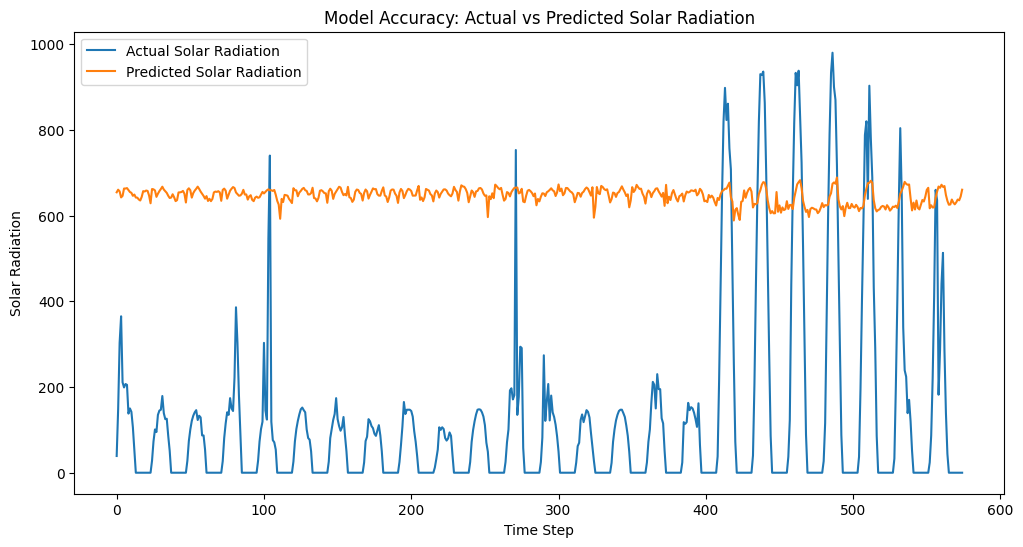

In [58]:
import matplotlib.pyplot as plt
import joblib
import torch

SEQ_LEN = 24
FEATURES = [
    "ALLSKY_SFC_SW_DIFF", "ALLSKY_SFC_SW_DNI", "TOA_SW_DWN",
    "RH2M", "QV2M", "PS", "WS2M", "CLOUD_AMT",
    "ALLSKY_SFC_LW_DWN", "T2M", "hour_sin", "hour_cos", "month_sin", "month_cos"
 ]
SCALER_PATH = "scalers/feature_scaler.pkl"

scaler = joblib.load(SCALER_PATH)
# model = DeepSolarModel(input_size=len(FEATURES))
# data = torch.load(MODEL_PATH)
# data = data['model_state']
# model.load_state_dict(data)
model.eval()

actual = []
predicted = []

for i in range(SEQ_LEN, len(df)-1):
    input_df = df.iloc[i-SEQ_LEN:i]
    input_features = input_df[FEATURES]
    input_scaled = scaler.transform(input_features)
    if input_scaled.shape[0] == SEQ_LEN:
        input_tensor = torch.tensor(input_scaled, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            pred = model(input_tensor).item()
        predicted.append(pred)
        actual.append(df.iloc[i+1]['solar_rad'])
    else:
        print(f"Skipped index {i}: input length {input_scaled.shape[0]} != 24")

plt.figure(figsize=(12,6))
plt.plot(actual, label='Actual Solar Radiation')
plt.plot(predicted, label='Predicted Solar Radiation')
plt.xlabel('Time Step')
plt.ylabel('Solar Radiation')
plt.title('Model Accuracy: Actual vs Predicted Solar Radiation')
plt.legend()
plt.show()